In [1]:
import pandas as pd
import numpy as np

# Create sample dataset with issues
data = {
    'EmpID': [101, 102, 103, 104, 104, 105],
    'Name': ['Arun', 'Bala', 'Divya', 'Priya', 'Priya', 'Ravi'],
    'Age': [25, np.nan, 28, 25, 25, 60],
    'Salary': [25000, 30000, np.nan, 25000, 25000, 150000],
    'Department': ['HR', 'IT', 'HR', 'HR', 'HR', 'Finance']
}

df = pd.DataFrame(data)
print(df)

   EmpID   Name   Age    Salary Department
0    101   Arun  25.0   25000.0         HR
1    102   Bala   NaN   30000.0         IT
2    103  Divya  28.0       NaN         HR
3    104  Priya  25.0   25000.0         HR
4    104  Priya  25.0   25000.0         HR
5    105   Ravi  60.0  150000.0    Finance


In [2]:
# Check for missing values
print(df.isnull())

   EmpID   Name    Age  Salary  Department
0  False  False  False   False       False
1  False  False   True   False       False
2  False  False  False    True       False
3  False  False  False   False       False
4  False  False  False   False       False
5  False  False  False   False       False


In [3]:
# Count missing values per column
print(df.isnull().sum())

EmpID         0
Name          0
Age           1
Salary        1
Department    0
dtype: int64


In [5]:
# Fill missing Age with mean age
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing Salary with mean salary
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

print(df)

   EmpID   Name   Age    Salary Department
0    101   Arun  25.0   25000.0         HR
1    102   Bala  32.6   30000.0         IT
2    103  Divya  28.0   51000.0         HR
3    104  Priya  25.0   25000.0         HR
4    104  Priya  25.0   25000.0         HR
5    105   Ravi  60.0  150000.0    Finance


In [6]:
# Check duplicates
print(df.duplicated())

0    False
1    False
2    False
3    False
4     True
5    False
dtype: bool


In [7]:
# Remove duplicates
df = df.drop_duplicates()
print(df)

   EmpID   Name   Age    Salary Department
0    101   Arun  25.0   25000.0         HR
1    102   Bala  32.6   30000.0         IT
2    103  Divya  28.0   51000.0         HR
3    104  Priya  25.0   25000.0         HR
5    105   Ravi  60.0  150000.0    Finance


In [8]:
# Detecting Outliers using IQR method
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]
print("Outliers:\n", outliers)

Outliers:
    EmpID  Name   Age    Salary Department
5    105  Ravi  60.0  150000.0    Finance


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Salary']] = scaler.fit_transform(df[['Salary']])
print(df[['Salary']])

   Salary
0   0.000
1   0.040
2   0.208
3   0.000
5   1.000


In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Department'] = encoder.fit_transform(df['Department'])
print(df)

   EmpID   Name   Age  Salary  Department
0    101   Arun  25.0   0.000           1
1    102   Bala  32.6   0.040           2
2    103  Divya  28.0   0.208           1
3    104  Priya  25.0   0.000           1
5    105   Ravi  60.0   1.000           0


In [11]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Department'])
print(df_encoded)

   EmpID   Name   Age  Salary  Department_0  Department_1  Department_2
0    101   Arun  25.0   0.000         False          True         False
1    102   Bala  32.6   0.040         False         False          True
2    103  Divya  28.0   0.208         False          True         False
3    104  Priya  25.0   0.000         False          True         False
5    105   Ravi  60.0   1.000          True         False         False


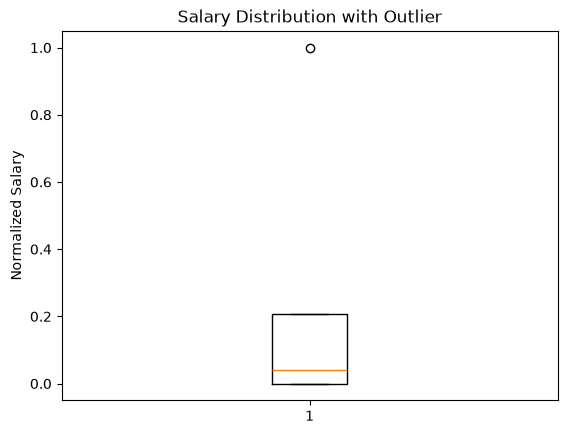

In [12]:
import matplotlib.pyplot as plt

# Box plot to show outlier
plt.boxplot(df['Salary'])
plt.title("Salary Distribution with Outlier")
plt.ylabel("Normalized Salary")
plt.show()